<a href="https://colab.research.google.com/github/jeanraposojesus-hue/Trabalho---PROCSIN/blob/main/Trabalho_PROCSIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 67.5 MB/s eta 0:00:00


In [ ]:
import fitz # PyMuPDF

# Caminho do arquivo
pdf_path = '/content/Trabalho___2026_1.pdf'

# Abrir o PDF e extrair o texto
doc = fitz.open(pdf_path)
full_text = ""
for page in doc:
    full_text += page.get_text()

# Exibir os primeiros 1000 caracteres para identificar a estrutura dos tópicos
print(full_text[:1000])

Prof. Rafael S. Chaves
Processamento de Sinais I
Modelagem e An´alise de Arranjos de Sensores
1
Objetivos
Este trabalho tem como objetivo introduzir conceitos
fundamentais de processamento espacial de sinais por
meio da modelagem e an´alise de arranjos de sensores.
Ao final da atividade, o aluno dever´a ser capaz de:
• Modelar
diferentes
geometrias
de
arranjos
de
sensores;
• Implementar fun¸c˜oes para gera¸c˜ao de canais de pro-
paga¸c˜ao;
• Compreender o conceito de vetor diretor (steering
vector);
• Implementar t´ecnicas b´asicas de beamforming;
• Calcular e interpretar diagramas de radia¸c˜ao (beam-
patterns);
• Avaliar a influˆencia da geometria do arranjo na re-
cep¸c˜ao de sinais;
• Relacionar ganho espacial, diretividade e potˆencia
recebida.
2
Fundamenta¸c˜ao Te´orica
Pesquise e apresente uma breve revis˜ao sobre:
1. Arranjos de sensores;
2. Processamento espacial de sinais;
3. Vetor diretor (steering vector);
4. Beamforming;
5. Beampattern;
6. Dire¸c˜ao de chegada (Direction o

In [ ]:
import re

# Procurando especificamente pelas seções 4, 5 e 6 no texto extraído
sections = re.split(r'\n(\d)\n', full_text)

content_4 = ""
content_5 = ""
content_6 = ""

for i in range(1, len(sections), 2):
    if sections[i] == '4':
        content_4 = sections[i+1]
    elif sections[i] == '5':
        content_5 = sections[i+1]
    elif sections[i] == '6':
        content_6 = sections[i+1]

print("--- Tópico 4 ---")
print(content_4[:1000])
print("\n--- Tópico 5 ---")
print(content_5[:1000])
print("\n--- Tópico 6 ---")
print(content_6[:1000])

--- Tópico 4 ---
Gera¸c˜ao das Geometrias
Desenvolva fun¸c˜oes para gerar as coordenadas tridimen-
sionais dos elementos dos seguintes arranjos.
Arranjo Linear Uniforme (ULA): Implementar
a
fun¸c˜ao positions = generate_ula(M, d),
onde
M ∈N ´e o n´umero de sensores e d ∈R+ ´e o
espa¸camento entre sensores.
Prof. Rafael S. Chaves
Processamento de Sinais I
Modelagem e An´alise de Arranjos de Sensores
Arranjo Circular Uniforme (UCA): Implementar
a fun¸c˜ao positions = generate_uca(M, R), onde
M ∈N ´e o n´umero de sensores e R ∈R+ ´e o raio
do c´ırculo.
Arranjo Planar Uniforme (UPA): Implementar
a
fun¸c˜ao
positions = generate_upa(Mx, My, dx
, dy), onde Mx ∈N ´e o n´umero de sensores na
dire¸c˜ao horizontal, My ∈N ´e o n´umero de sensores
na dire¸c˜ao vertical, dx
∈R+ ´e o espa¸camento
horizontal e dy ∈R+ ´e o espa¸camento vertical.
Arranjo Cil´ındrico Uniforme: Implementar
a
fun¸c˜ao
positions = generate_ucya(Mc, Nz, R
, dz), onde Mc ∈N ´e o n´umero de sensores por
anel, Nz ∈N ´e o n´umer

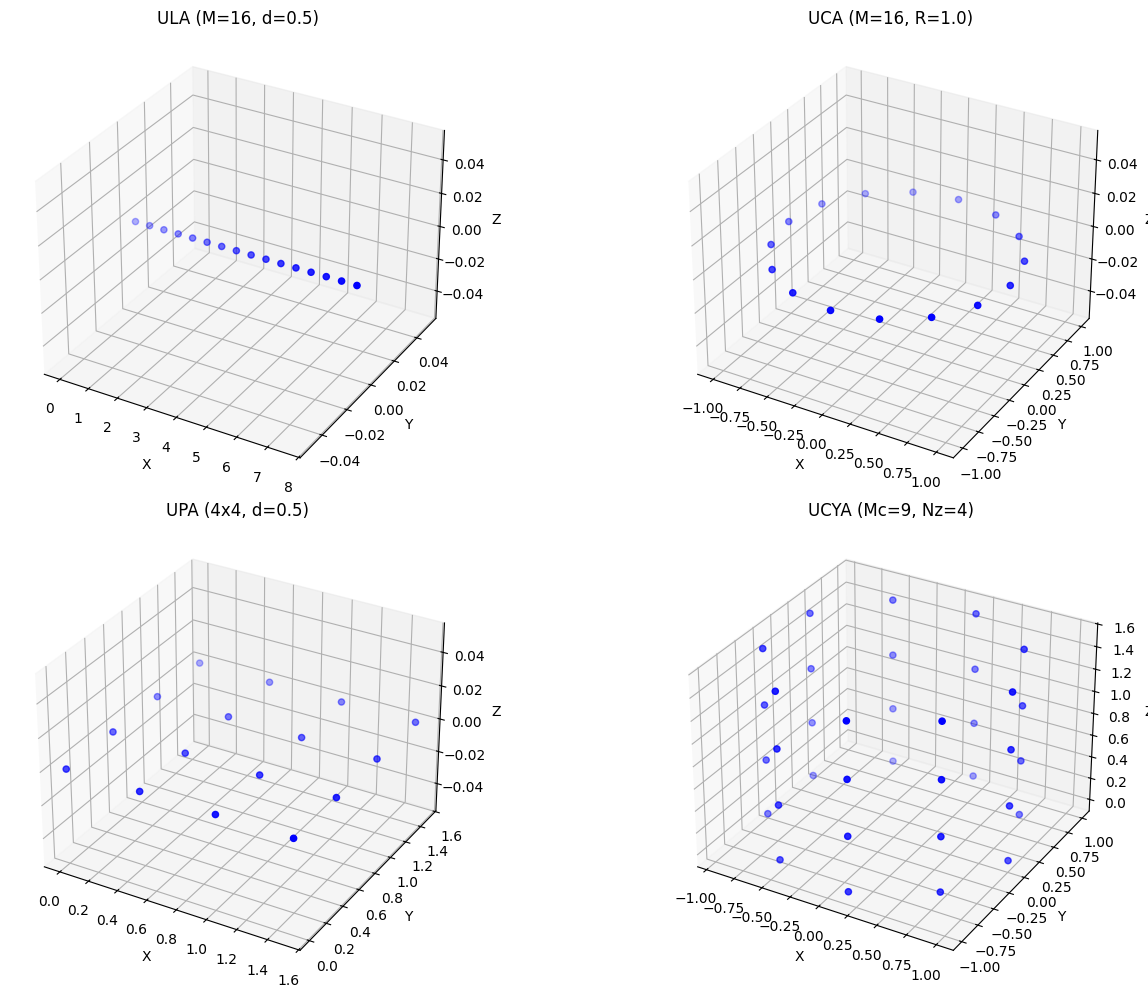

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_ula(M, d):
    """Arranjo Linear Uniforme (ULA)"""
    positions = np.zeros((M, 3))
    positions[:, 0] = np.arange(M) * d
    return positions

def generate_uca(M, R):
    """Arranjo Circular Uniforme (UCA)"""
    positions = np.zeros((M, 3))
    angles = np.linspace(0, 2 * np.pi, M, endpoint=False)
    positions[:, 0] = R * np.cos(angles)
    positions[:, 1] = R * np.sin(angles)
    return positions

def generate_upa(Mx, My, dx, dy):
    """Arranjo Planar Uniforme (UPA)"""
    positions = np.zeros((Mx * My, 3))
    for i in range(My):
        for j in range(Mx):
            positions[i * Mx + j, 0] = j * dx
            positions[i * Mx + j, 1] = i * dy
    return positions

def generate_ucya(Mc, Nz, R, dz):
    """Arranjo Cilíndrico Uniforme (UCYA)"""
    positions = np.zeros((Mc * Nz, 3))
    angles = np.linspace(0, 2 * np.pi, Mc, endpoint=False)
    for i in range(Nz):
        positions[i * Mc : (i + 1) * Mc, 0] = R * np.cos(angles)
        positions[i * Mc : (i + 1) * Mc, 1] = R * np.sin(angles)
        positions[i * Mc : (i + 1) * Mc, 2] = i * dz
    return positions

# Exemplo de visualização das geometrias
fig = plt.figure(figsize=(15, 10))
geoms = [
    (generate_ula(16, 0.5), "ULA (M=16, d=0.5)"),
    (generate_uca(16, 1.0), "UCA (M=16, R=1.0)"),
    (generate_upa(4, 4, 0.5, 0.5), "UPA (4x4, d=0.5)"),
    (generate_ucya(9, 4, 1.0, 0.5), "UCYA (Mc=9, Nz=4)")
]

for i, (pos, title) in enumerate(geoms):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c='blue', marker='o')
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
plt.tight_layout()
plt.show()

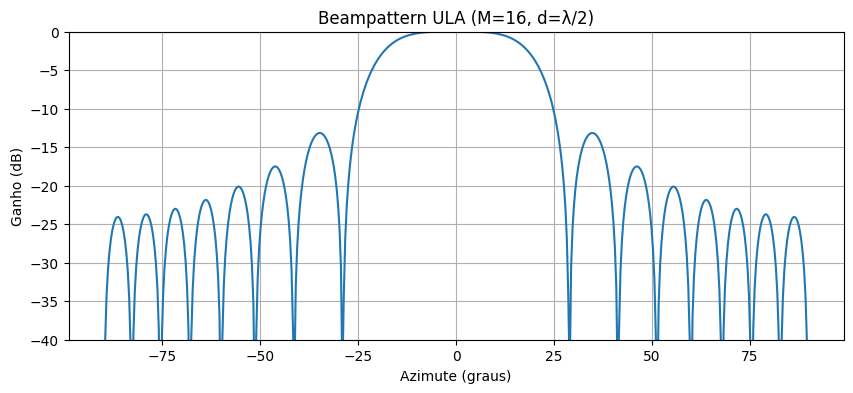

In [ ]:
def steering_vector(positions, azimuth, elevation, wavelength):
    """Calcula o vetor diretor para azimute (phi) e elevação (theta) em graus."""
    k = 2 * np.pi / wavelength
    az_rad = np.deg2rad(azimuth)
    el_rad = np.deg2rad(elevation)
    # Vetor unitário apontando para a direção desejada
    u = np.array([
        np.cos(el_rad) * np.cos(az_rad),
        np.cos(el_rad) * np.sin(az_rad),
        np.sin(el_rad)
    ])
    # s = exp(j * k * pos . u)
    phases = np.dot(positions, u)
    return np.exp(1j * k * phases)

def beampattern(positions, az_range, el_range, wavelength, steer_az=0, steer_el=0):
    """Gera o diagrama de radiação normalizado em dB."""
    w = steering_vector(positions, steer_az, steer_el, wavelength)
    B = []
    for az in az_range:
        for el in el_range:
            sv = steering_vector(positions, az, el, wavelength)
            gain = np.abs(np.vdot(w, sv))
            B.append(gain)
    B = np.array(B).reshape(len(az_range), len(el_range))
    B_db = 20 * np.log10(B / np.max(B))
    return B_db

# Exemplo de Beampattern para ULA (M=16, d=lambda/2)
wav = 1.0
az_vals = np.linspace(-90, 90, 500)
B_ula = beampattern(generate_ula(16, wav/2), az_vals, [0], wav)

plt.figure(figsize=(10, 4))
plt.plot(az_vals, B_ula)
plt.title("Beampattern ULA (M=16, d=λ/2)")
plt.xlabel("Azimute (graus)")
plt.ylabel("Ganho (dB)")
plt.ylim([-40, 0])
plt.grid(True)
plt.show()

In [ ]:
def beamformer(x, positions, steer_az, steer_el, wavelength):
    """Implementa o Delay-and-Sum Beamformer (Tópico 6)."""
    w = steering_vector(positions, steer_az, steer_el, wavelength)
    # y = w^H * x
    return np.dot(w.conj().T, x)

print("Implementações dos tópicos 4, 5 e 6 concluídas.")

Implementações dos tópicos 4, 5 e 6 concluídas.


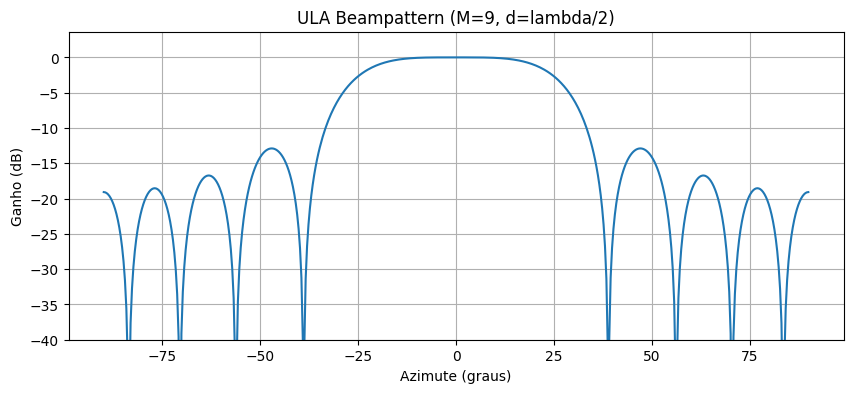

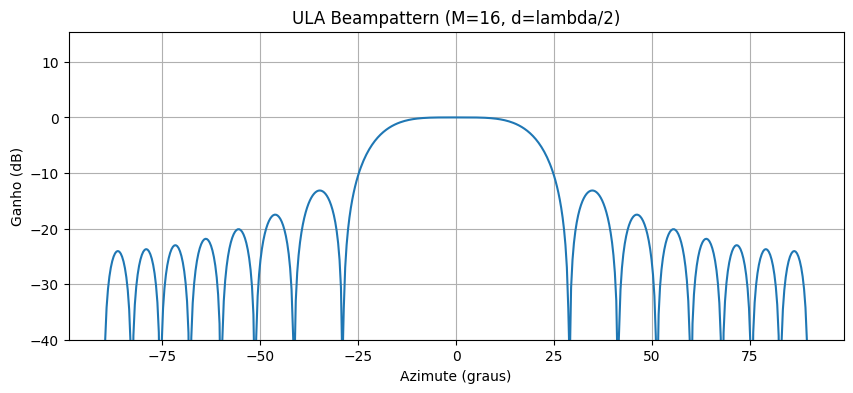

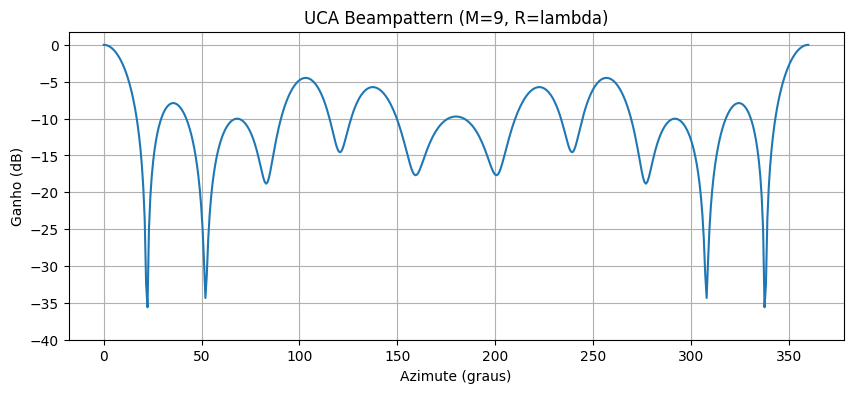

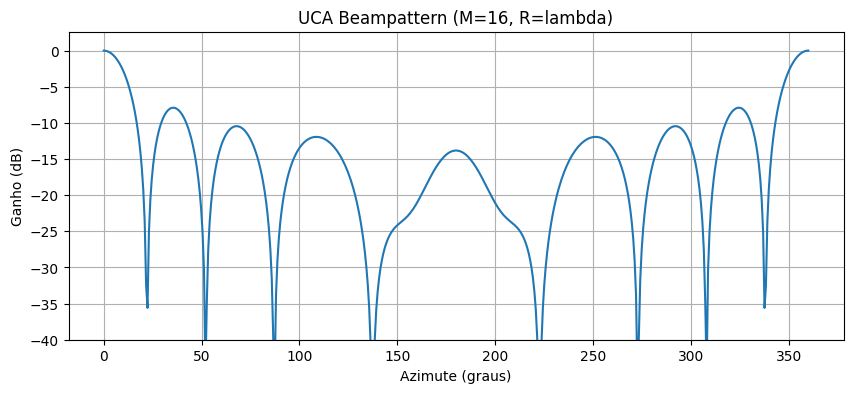

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_beampattern(positions, az_range, el_range, wav, title, steer_az=0, steer_el=0):
    B_db = beampattern(positions, az_range, el_range, wav, steer_az, steer_el)

    plt.figure(figsize=(10, 4))
    if len(el_range) == 1:
        plt.plot(az_range, B_db)
        plt.ylabel('Ganho (dB)')
        plt.xlabel('Azimute (graus)')
    else:
        extent = [el_range[0], el_range[-1], az_range[0], az_range[-1]]
        plt.imshow(B_db, extent=extent, aspect='auto', origin='lower', cmap='jet')
        plt.colorbar(label='Ganho (dB)')
        plt.ylabel('Azimute (graus)')
        plt.xlabel('Elevação (graus)')

    plt.title(title)
    plt.grid(True)
    plt.ylim(bottom=-40)
    plt.show()

# --- 5. ULA: M={9, 16}, d=lambda/2 ---
wav = 1.0
azs = np.linspace(-90, 90, 500)
for M in [9, 16]:
    analyze_beampattern(generate_ula(M, wav/2), azs, [0], wav, f'ULA Beampattern (M={M}, d=lambda/2)')

# --- 5. UCA: M={9, 16}, R=lambda ---
phi_range = np.linspace(0, 360, 500)
for M in [9, 16]:
    analyze_beampattern(generate_uca(M, wav), phi_range, [0], wav, f'UCA Beampattern (M={M}, R=lambda)')

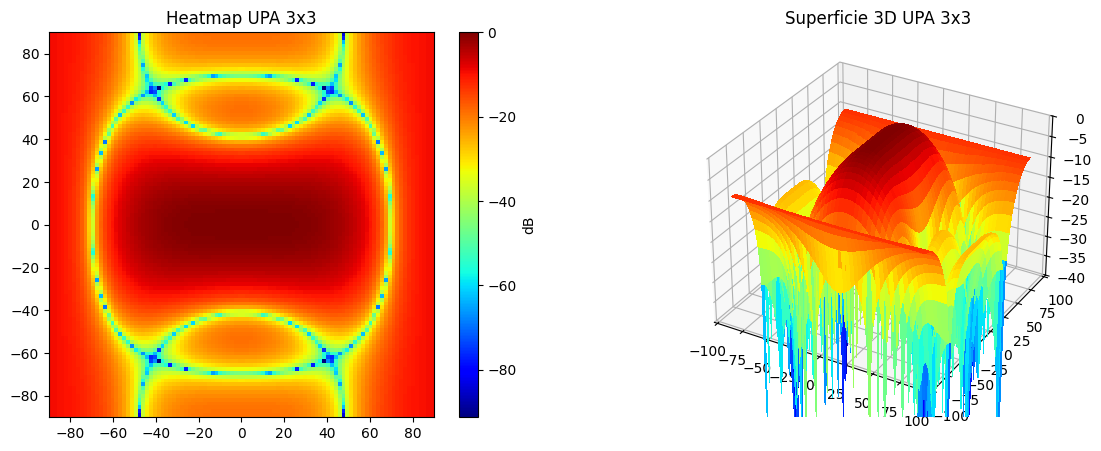

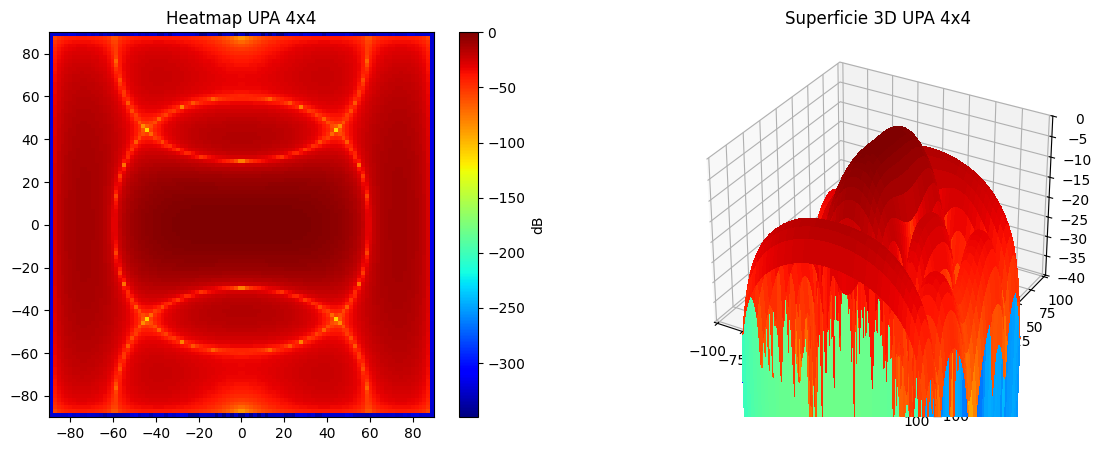

In [ ]:
from matplotlib import cm

# --- 5. UPA: MxM {3, 4}, dx=dy=lambda/2 ---
wav = 1.0
az_range = np.linspace(-90, 90, 100)
el_range = np.linspace(-90, 90, 100)

for M in [3, 4]:
    positions_upa = generate_upa(M, M, wav/2, wav/2)
    B_db = beampattern(positions_upa, az_range, el_range, wav)

    fig = plt.figure(figsize=(14, 5))
    # Heatmap
    ax1 = fig.add_subplot(1, 2, 1)
    im = ax1.imshow(B_db, extent=[-90, 90, -90, 90], origin='lower', cmap='jet')
    plt.colorbar(im, ax=ax1, label='dB')
    ax1.set_title(f'Heatmap UPA {M}x{M}')

    # 3D Surface
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    EL, AZ = np.meshgrid(el_range, az_range)
    surf = ax2.plot_surface(AZ, EL, B_db, cmap='jet', linewidth=0, antialiased=False)
    ax2.set_title(f'Superficie 3D UPA {M}x{M}')
    ax2.set_zlim(-40, 0)
    plt.show()

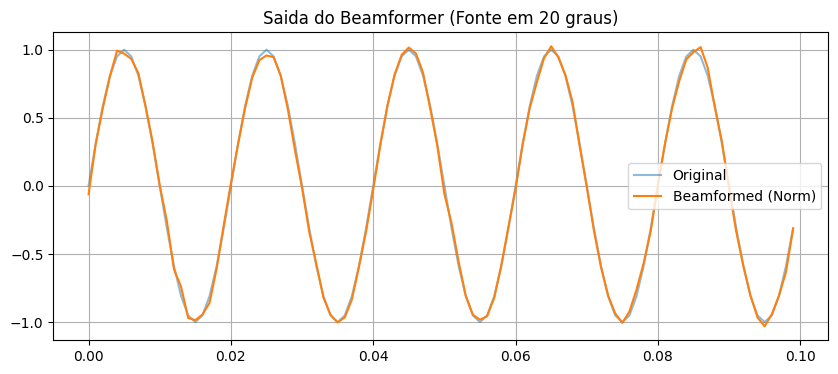

In [ ]:
# --- Tópico 6: Exemplo de Beamforming ---
fs = 1000
t = np.arange(0, 0.1, 1/fs)
signal = np.sin(2*np.pi*50*t)
theta_soi = 20
pos_ula = generate_ula(16, wav/2)
a_soi = steering_vector(pos_ula, theta_soi, 0, wav)
# Sinal com ruido
x = np.outer(a_soi, signal) + 0.1*(np.random.randn(16, len(t)) + 1j*np.random.randn(16, len(t)))
y = beamformer(x, pos_ula, 20, 0, wav)

plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Original', alpha=0.5)
plt.plot(t, np.real(y)/16, label='Beamformed (Norm)')
plt.title('Saida do Beamformer (Fonte em 20 graus)')
plt.legend()
plt.grid(True)
plt.show()

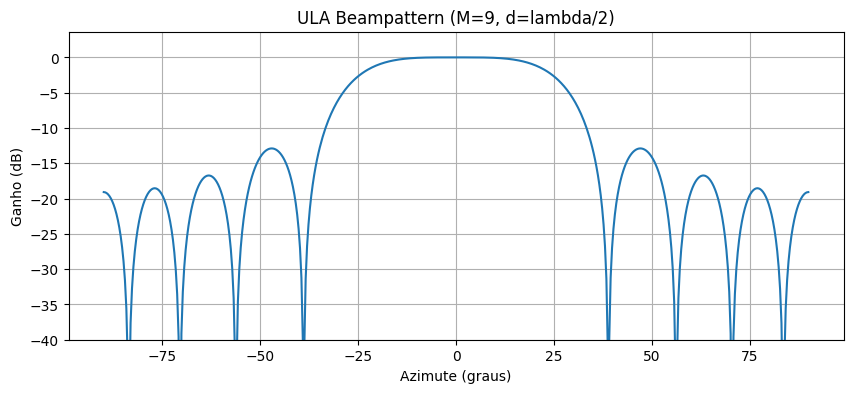

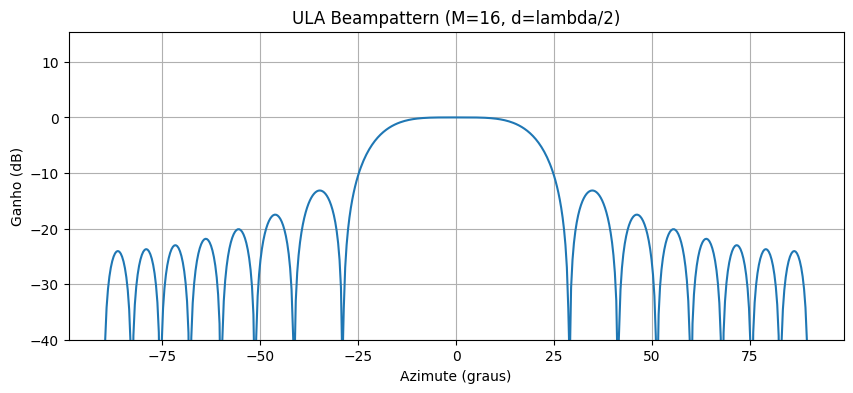

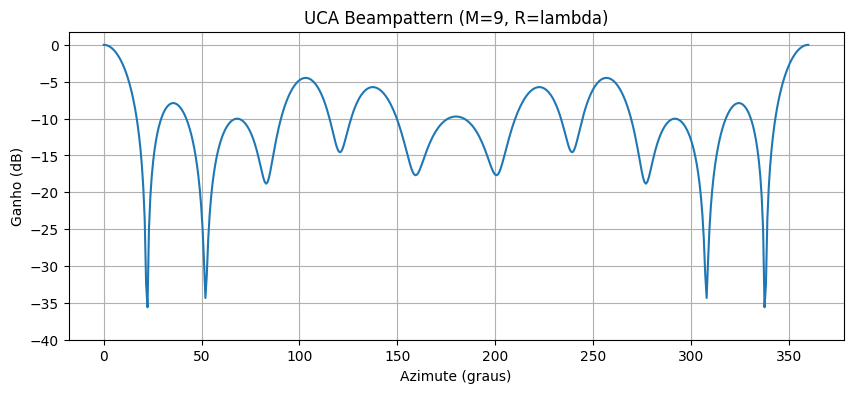

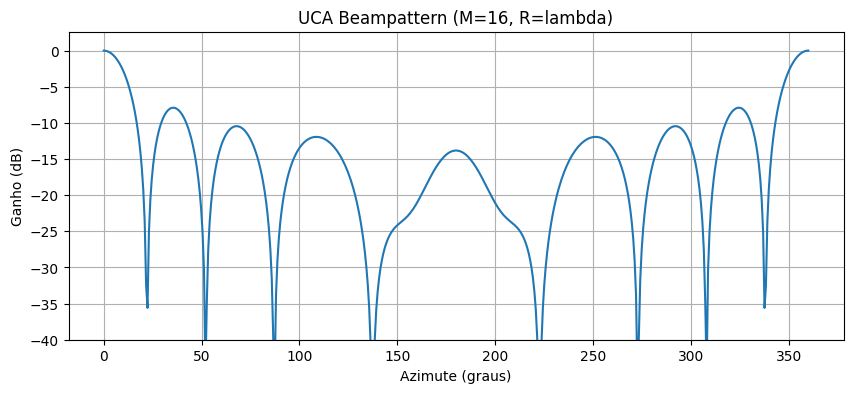

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_beampattern(positions, az_range, el_range, wav, title, steer_az=0, steer_el=0):
    B_db = beampattern(positions, az_range, el_range, wav, steer_az, steer_el)

    plt.figure(figsize=(10, 4))
    if len(el_range) == 1:
        plt.plot(az_range, B_db)
        plt.ylabel('Ganho (dB)')
        plt.xlabel('Azimute (graus)')
    else:
        extent = [el_range[0], el_range[-1], az_range[0], az_range[-1]]
        plt.imshow(B_db, extent=extent, aspect='auto', origin='lower', cmap='jet')
        plt.colorbar(label='Ganho (dB)')
        plt.ylabel('Azimute (graus)')
        plt.xlabel('Elevação (graus)')

    plt.title(title)
    plt.grid(True)
    plt.ylim(bottom=-40)
    plt.show()

# --- 5. ULA: M={9, 16}, d=lambda/2 ---
wav = 1.0
azs = np.linspace(-90, 90, 500)
for M in [9, 16]:
    analyze_beampattern(generate_ula(M, wav/2), azs, [0], wav, f'ULA Beampattern (M={M}, d=lambda/2)')

# --- 5. UCA: M={9, 16}, R=lambda ---
phi_range = np.linspace(0, 360, 500)
for M in [9, 16]:
    analyze_beampattern(generate_uca(M, wav), phi_range, [0], wav, f'UCA Beampattern (M={M}, R=lambda)')

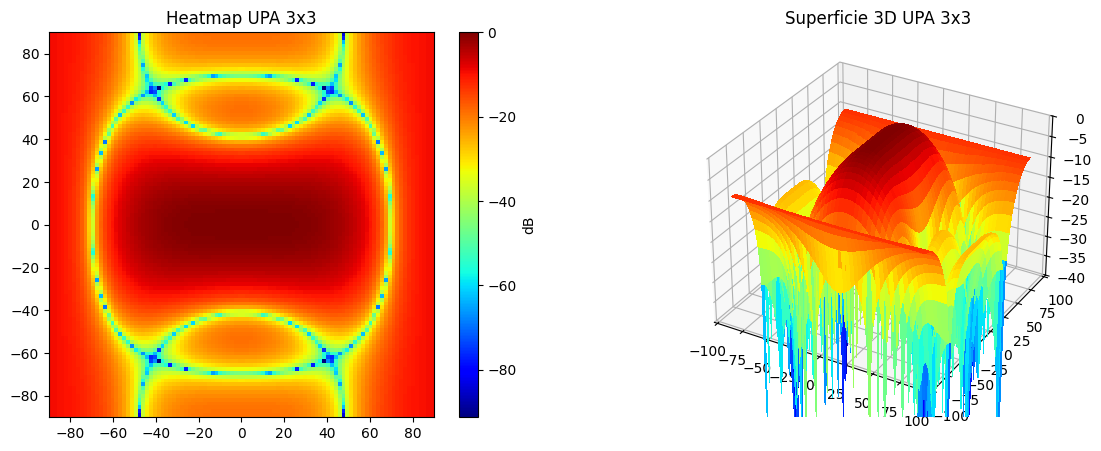

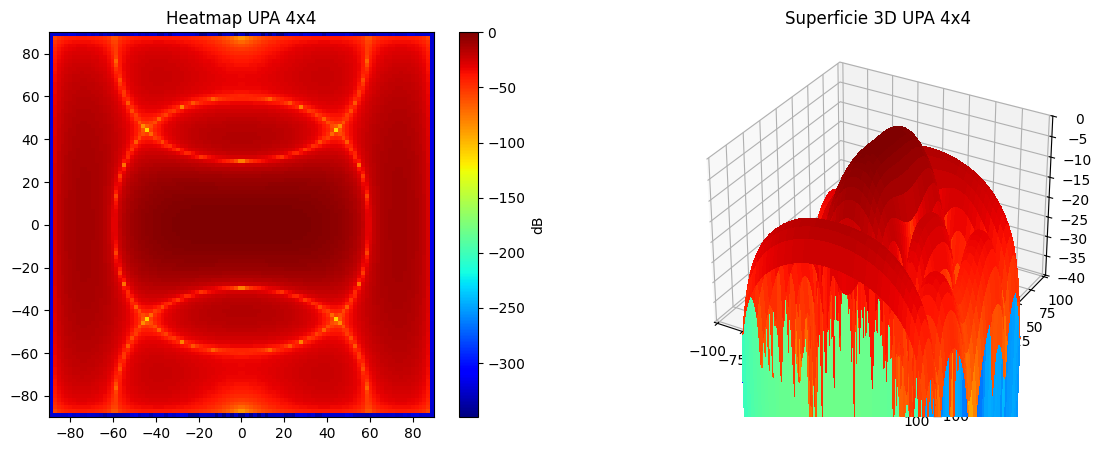

In [ ]:
from matplotlib import cm

# --- 5. UPA: MxM {3, 4}, dx=dy=lambda/2 ---
wav = 1.0
az_range = np.linspace(-90, 90, 100)
el_range = np.linspace(-90, 90, 100)

for M in [3, 4]:
    positions_upa = generate_upa(M, M, wav/2, wav/2)
    B_db = beampattern(positions_upa, az_range, el_range, wav)

    fig = plt.figure(figsize=(14, 5))
    # Heatmap
    ax1 = fig.add_subplot(1, 2, 1)
    im = ax1.imshow(B_db, extent=[-90, 90, -90, 90], origin='lower', cmap='jet')
    plt.colorbar(im, ax=ax1, label='dB')
    ax1.set_title(f'Heatmap UPA {M}x{M}')

    # 3D Surface
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    EL, AZ = np.meshgrid(el_range, az_range)
    surf = ax2.plot_surface(AZ, EL, B_db, cmap='jet', linewidth=0, antialiased=False)
    ax2.set_title(f'Superficie 3D UPA {M}x{M}')
    ax2.set_zlim(-40, 0)
    plt.show()

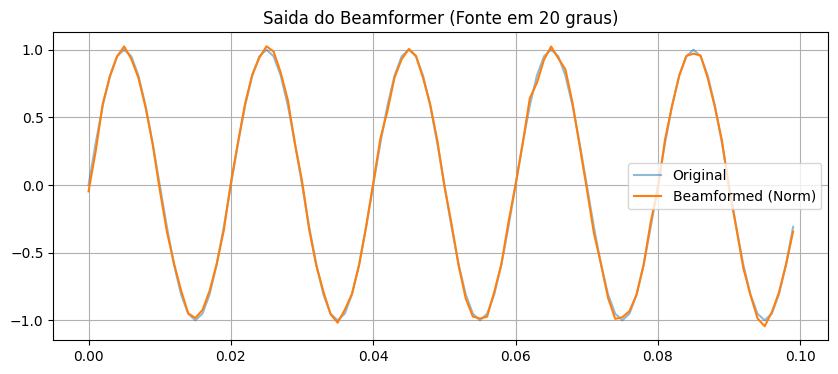

In [ ]:
# --- Tópico 6: Exemplo de Beamforming ---
fs = 1000
t = np.arange(0, 0.1, 1/fs)
signal = np.sin(2*np.pi*50*t)
theta_soi = 20
pos_ula = generate_ula(16, wav/2)
a_soi = steering_vector(pos_ula, theta_soi, 0, wav)
# Sinal com ruido
x = np.outer(a_soi, signal) + 0.1*(np.random.randn(16, len(t)) + 1j*np.random.randn(16, len(t)))
y = beamformer(x, pos_ula, 20, 0, wav)

plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Original', alpha=0.5)
plt.plot(t, np.real(y)/16, label='Beamformed (Norm)')
plt.title('Saida do Beamformer (Fonte em 20 graus)')
plt.legend()
plt.grid(True)
plt.show()

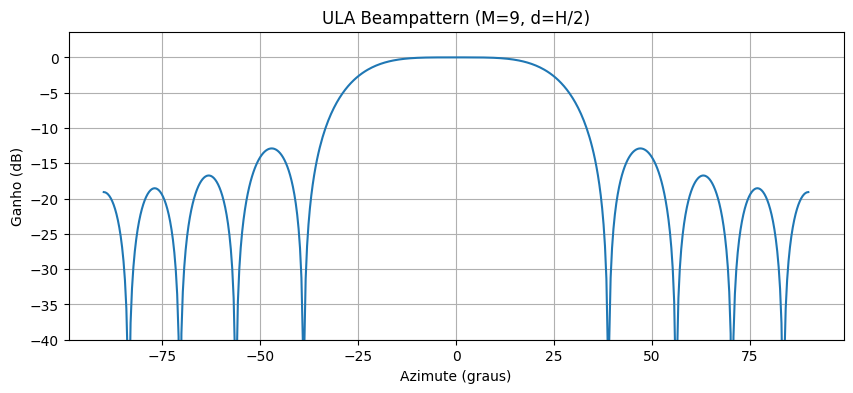

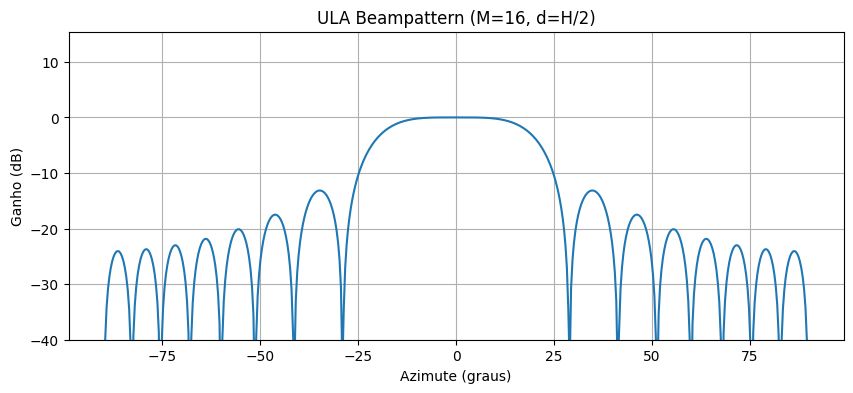

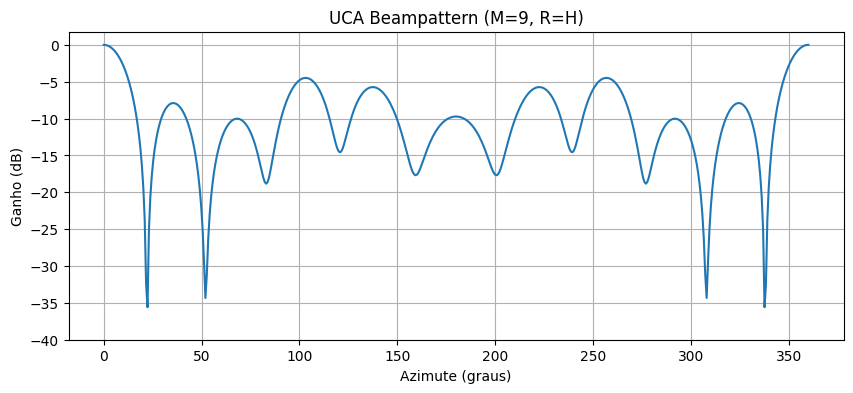

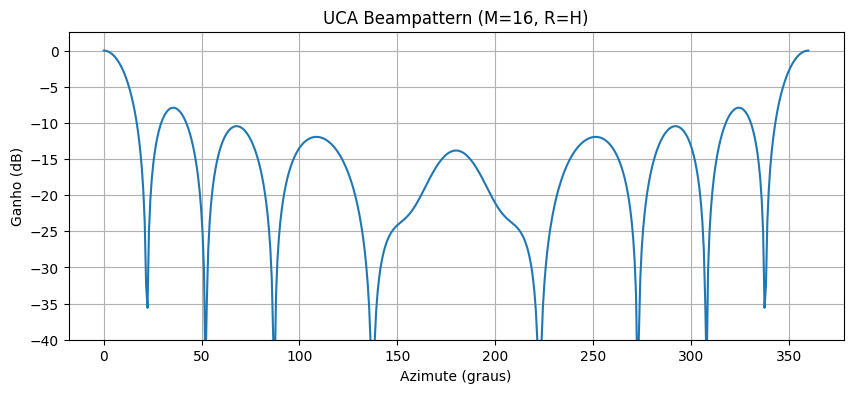

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_beampattern(positions, az_range, el_range, wav, title, steer_az=0, steer_el=0):
    B_db = beampattern(positions, az_range, el_range, wav, steer_az, steer_el)

    plt.figure(figsize=(10, 4))
    if len(el_range) == 1:
        plt.plot(az_range, B_db)
        plt.ylabel('Ganho (dB)')
        plt.xlabel('Azimute (graus)')
    else:
        extent = [el_range[0], el_range[-1], az_range[0], az_range[-1]]
        plt.imshow(B_db, extent=extent, aspect='auto', origin='lower', cmap='jet')
        plt.colorbar(label='Ganho (dB)')
        plt.ylabel('Azimute (graus)')
        plt.xlabel('Elevação (graus)')

    plt.title(title)
    plt.grid(True)
    plt.ylim(bottom=-40)
    plt.show()

# --- 5. ULA: M={9, 16}, d=lambda/2 ---
wav = 1.0
azs = np.linspace(-90, 90, 500)
for M in [9, 16]:
    analyze_beampattern(generate_ula(M, wav/2), azs, [0], wav, f"ULA Beampattern (M={M}, d=Η/2)")

# --- 5. UCA: M={9, 16}, R=lambda ---
phi_range = np.linspace(0, 360, 500)
for M in [9, 16]:
    analyze_beampattern(generate_uca(M, wav), phi_range, [0], wav, f"UCA Beampattern (M={M}, R=Η)")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


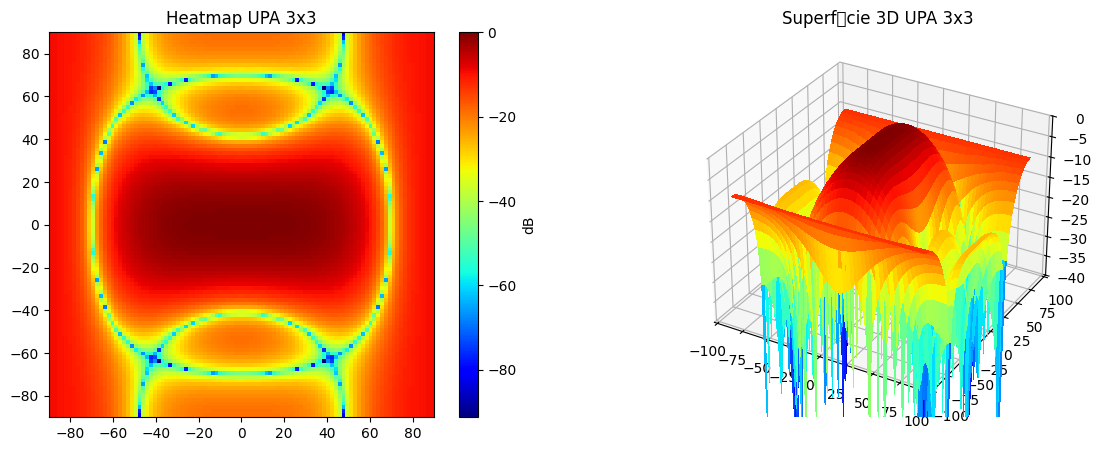

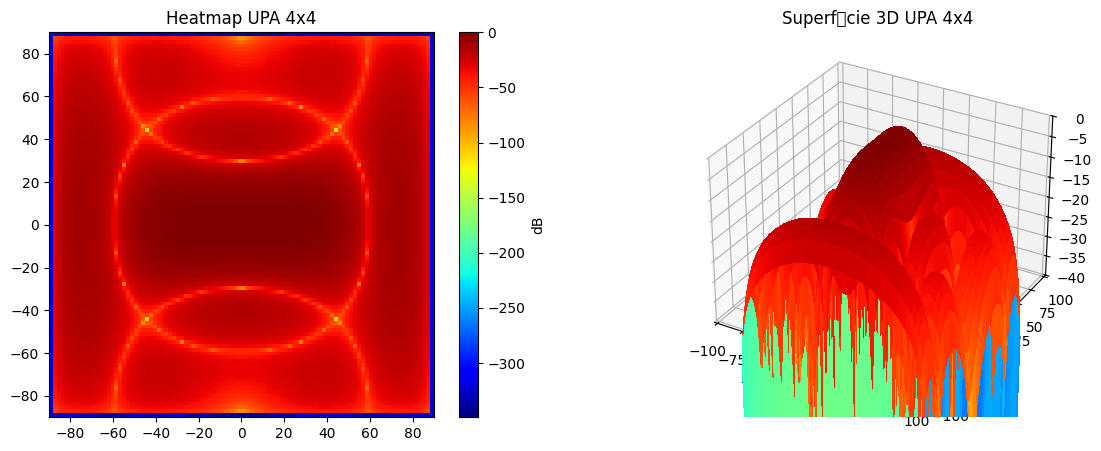

In [ ]:
from matplotlib import cm

# --- 5. UPA: MxM {3, 4}, dx=dy=lambda/2 ---
wav = 1.0
az_range = np.linspace(-90, 90, 100)
el_range = np.linspace(-90, 90, 100)

for M in [3, 4]:
    positions_upa = generate_upa(M, M, wav/2, wav/2)
    B_db = beampattern(positions_upa, az_range, el_range, wav)

    fig = plt.figure(figsize=(14, 5))
    # Heatmap
    ax1 = fig.add_subplot(1, 2, 1)
    im = ax1.imshow(B_db, extent=[-90, 90, -90, 90], origin='lower', cmap='jet')
    plt.colorbar(im, ax=ax1, label='dB')
    ax1.set_title(f'Heatmap UPA {M}x{M}')

    # 3D Surface
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    EL, AZ = np.meshgrid(el_range, az_range)
    surf = ax2.plot_surface(AZ, EL, B_db, cmap='jet', linewidth=0, antialiased=False)
    ax2.set_title(f'Superfcie 3D UPA {M}x{M}')
    ax2.set_zlim(-40, 0)
    plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


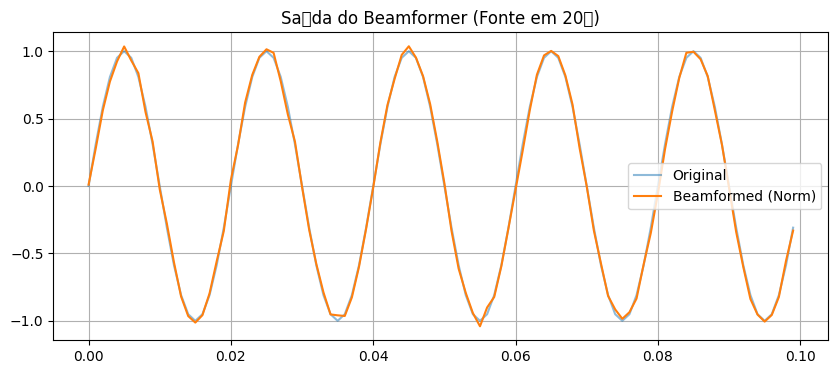

In [ ]:
# --- Tpico 6: Exemplo de Beamforming ---
fs = 1000
t = np.arange(0, 0.1, 1/fs)
signal = np.sin(2*np.pi*50*t)
theta_soi = 20
pos_ula = generate_ula(16, wav/2)
a_soi = steering_vector(pos_ula, theta_soi, 0, wav)
# Sinal com rudo
x = np.outer(a_soi, signal) + 0.1*(np.random.randn(16, len(t)) + 1j*np.random.randn(16, len(t)))
y = beamformer(x, pos_ula, 20, 0, wav)

plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Original', alpha=0.5)
plt.plot(t, np.real(y)/16, label='Beamformed (Norm)')
plt.title("Sada do Beamformer (Fonte em 20)")
plt.legend()
plt.grid(True)
plt.show()

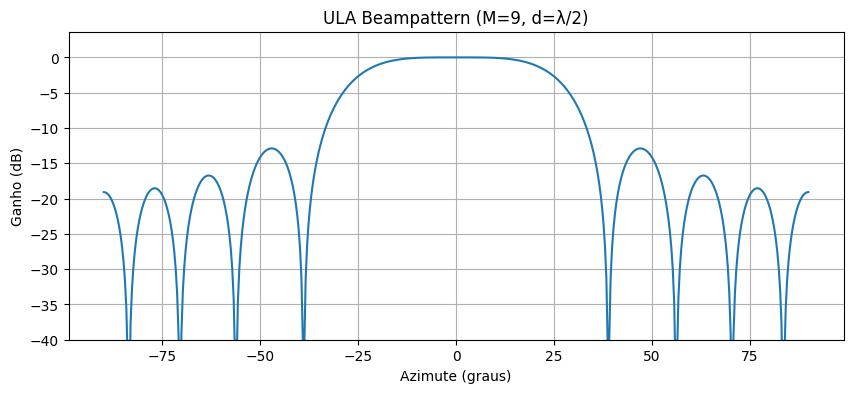

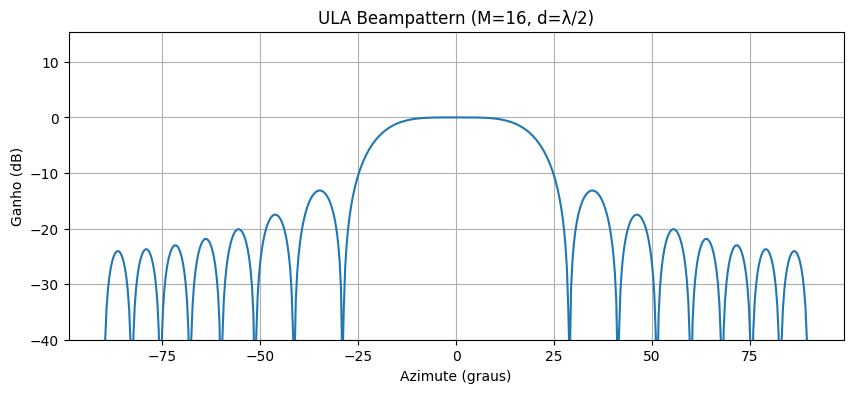

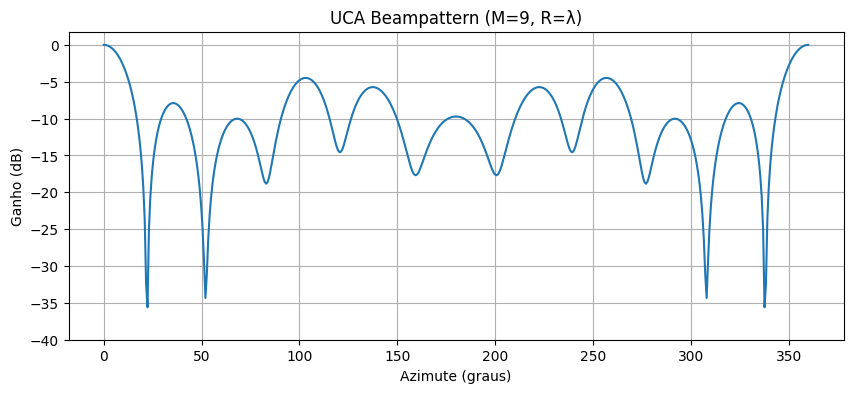

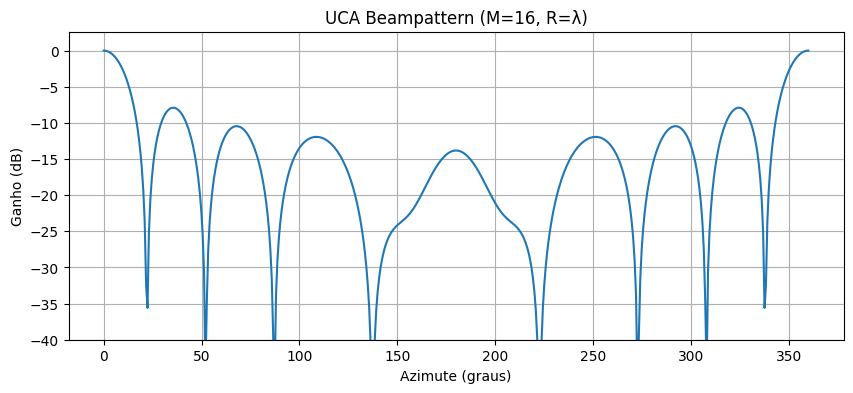

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_beampattern(positions, az_range, el_range, wav, title, steer_az=0, steer_el=0):
    B_db = beampattern(positions, az_range, el_range, wav, steer_az, steer_el)

    plt.figure(figsize=(10, 4))
    if len(el_range) == 1:
        plt.plot(az_range, B_db)
        plt.ylabel('Ganho (dB)')
        plt.xlabel('Azimute (graus)')
    else:
        extent = [el_range[0], el_range[-1], az_range[0], az_range[-1]]
        plt.imshow(B_db, extent=extent, aspect='auto', origin='lower', cmap='jet')
        plt.colorbar(label='Ganho (dB)')
        plt.ylabel('Azimute (graus)')
        plt.xlabel('Elevação (graus)')

    plt.title(title)
    plt.grid(True)
    plt.ylim(bottom=-40)
    plt.show()

# --- 5. ULA: M={9, 16}, d=lambda/2 ---
wav = 1.0
azs = np.linspace(-90, 90, 500)
for M in [9, 16]:
    analyze_beampattern(generate_ula(M, wav/2), azs, [0], wav, f"ULA Beampattern (M={M}, d=λ/2)")

# --- 5. UCA: M={9, 16}, R=lambda ---
phi_range = np.linspace(0, 360, 500)
for M in [9, 16]:
    analyze_beampattern(generate_uca(M, wav), phi_range, [0], wav, f"UCA Beampattern (M={M}, R=λ)")

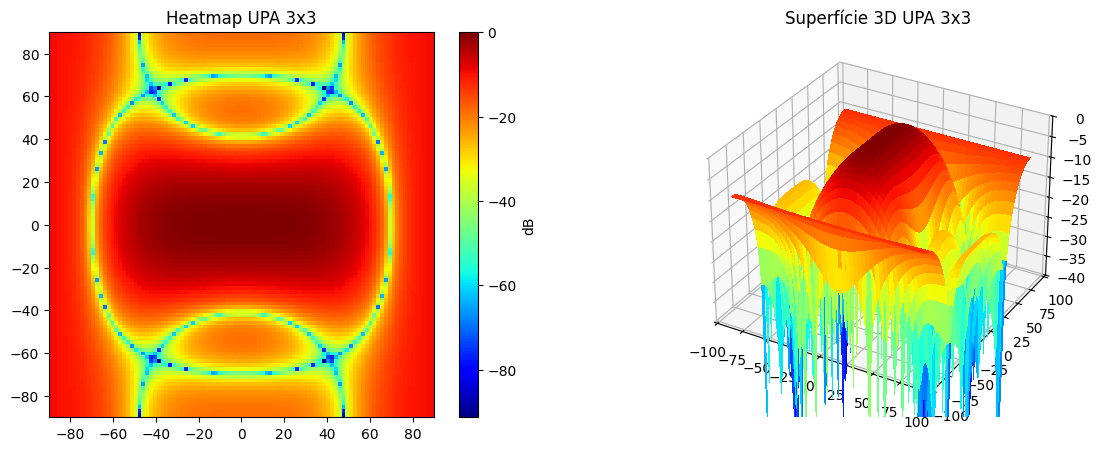

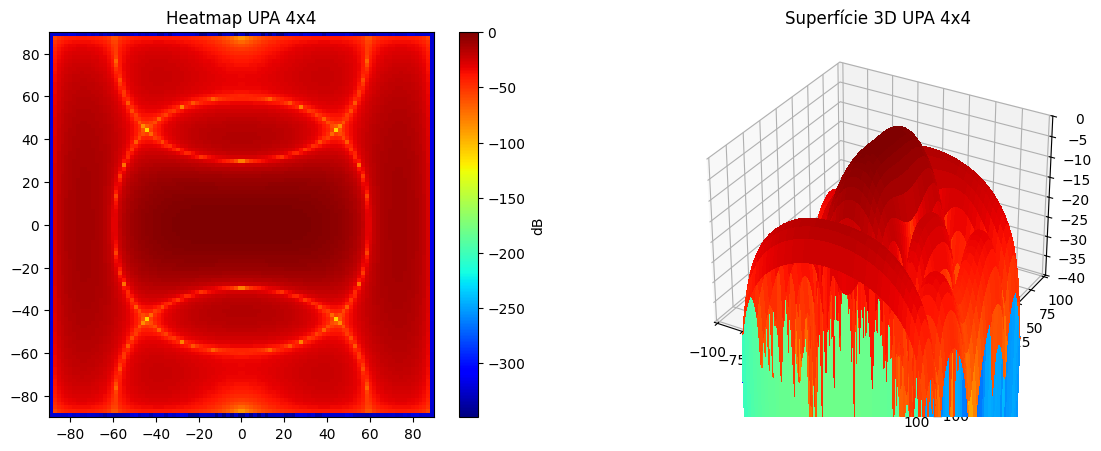

In [ ]:
from matplotlib import cm

# --- 5. UPA: MxM {3, 4}, dx=dy=lambda/2 ---
wav = 1.0
az_range = np.linspace(-90, 90, 100)
el_range = np.linspace(-90, 90, 100)

for M in [3, 4]:
    positions_upa = generate_upa(M, M, wav/2, wav/2)
    B_db = beampattern(positions_upa, az_range, el_range, wav)

    # Plot Heatmap
    fig = plt.figure(figsize=(14, 5))
    ax1 = fig.add_subplot(1, 2, 1)
    im = ax1.imshow(B_db, extent=[-90, 90, -90, 90], origin='lower', cmap='jet')
    plt.colorbar(im, ax=ax1, label='dB')
    ax1.set_title(f'Heatmap UPA {M}x{M}')

    # Plot 3D Surface
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    EL, AZ = np.meshgrid(el_range, az_range)
    surf = ax2.plot_surface(AZ, EL, B_db, cmap='jet', linewidth=0, antialiased=False)
    ax2.set_title(f'Superfície 3D UPA {M}x{M}')
    ax2.set_zlim(-40, 0)
    plt.show()

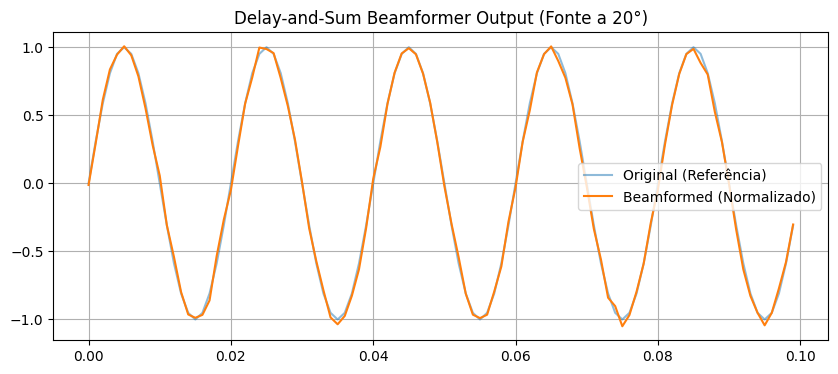

In [ ]:
# --- Tópico 6: Exemplo de Beamforming ---
# Simulando um sinal chegando de 20 graus de azimute
fs = 1000
t = np.arange(0, 0.1, 1/fs)
signal = np.sin(2*np.pi*50*t) # Senoide de 50Hz

# Direção da fonte (SOI)
theta_soi = 20
pos_ula = generate_ula(16, wav/2)

# Vetor diretor da fonte
a_soi = steering_vector(pos_ula, theta_soi, 0, wav)

# Sinais recebidos nos sensores (M x N_amostras)
x = np.outer(a_soi, signal) + 0.1*(np.random.randn(16, len(t)) + 1j*np.random.randn(16, len(t)))

# Aplicando Beamformer apontado para a fonte (20 graus)
y = beamformer(x, pos_ula, 20, 0, wav)

plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Original (Referência)', alpha=0.5)
plt.plot(t, np.real(y)/16, label='Beamformed (Normalizado)')
plt.title("Delay-and-Sum Beamformer Output (Fonte a 20°)")
plt.legend()
plt.grid(True)
plt.show()

### Visualização do Beampattern para o Arranjo Cilíndrico (UCYA)
Conforme o Tópico 5 do PDF, para o arranjo cilíndrico devemos apresentar:
- Mapa de calor (2D)
- Superfície tridimensional (3D)
- Identificação de lóbulos e largura de feixe (análise visual).

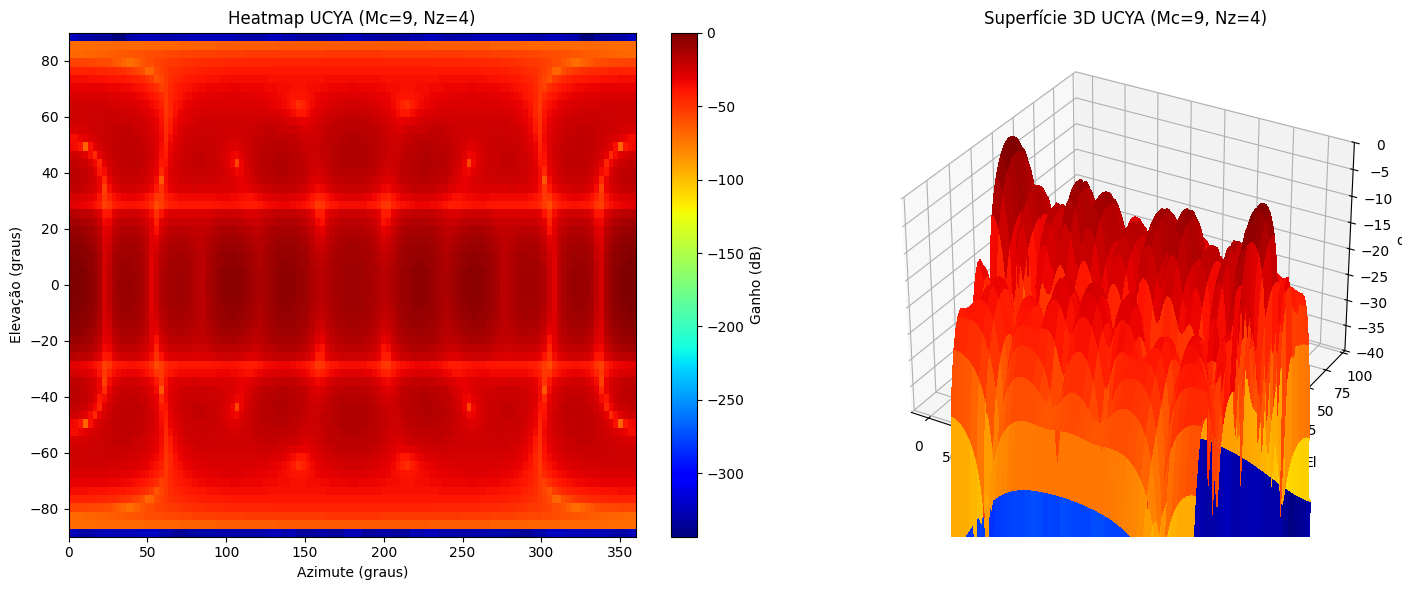

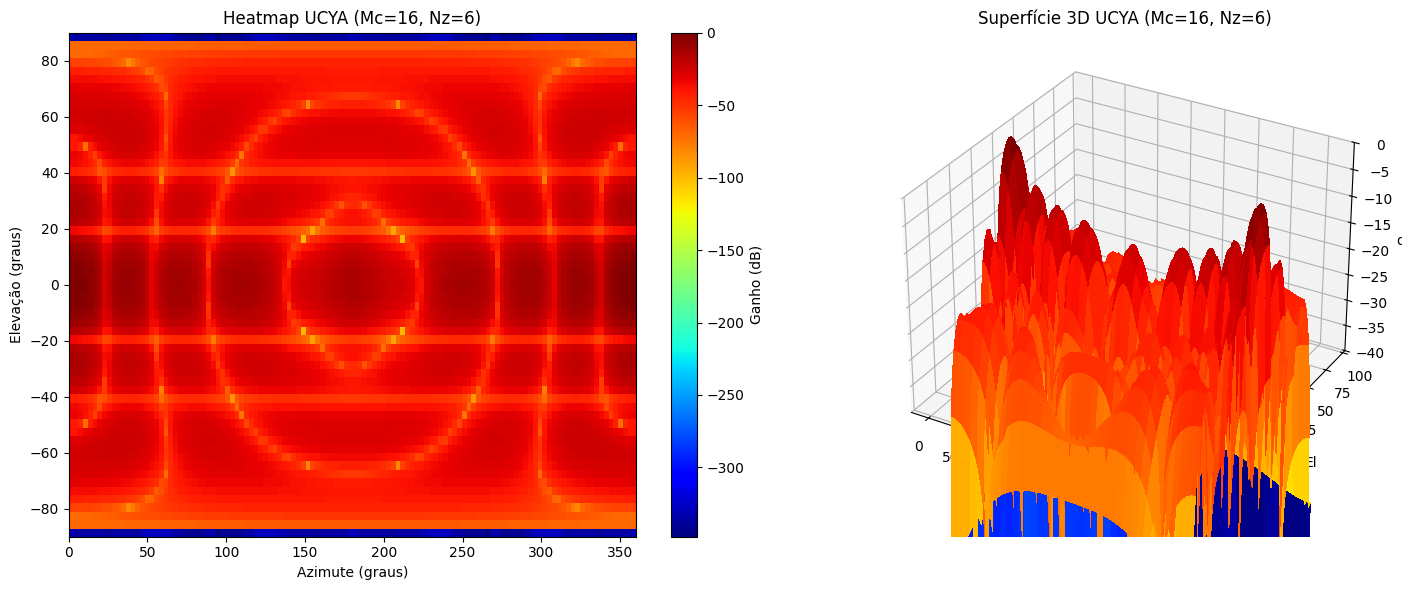

In [ ]:
wav = 1.0
az_range = np.linspace(0, 360, 120)
el_range = np.linspace(-90, 90, 60)

# Parâmetros solicitados: Mc=9, Nz=4 e Mc=16, Nz=6
configs = [(9, 4), (16, 6)]

for Mc, Nz in configs:
    pos_ucya = generate_ucya(Mc, Nz, R=wav, dz=wav/2)
    B_db = beampattern(pos_ucya, az_range, el_range, wav)

    fig = plt.figure(figsize=(15, 6))

    # 1. Heatmap
    ax1 = fig.add_subplot(1, 2, 1)
    im = ax1.imshow(B_db.T, extent=[0, 360, -90, 90], origin='lower', cmap='jet', aspect='auto')
    plt.colorbar(im, ax=ax1, label='Ganho (dB)')
    ax1.set_title(f'Heatmap UCYA (Mc={Mc}, Nz={Nz})')
    ax1.set_xlabel('Azimute (graus)')
    ax1.set_ylabel('Elevação (graus)')

    # 2. Superfície 3D
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    AZ, EL = np.meshgrid(az_range, el_range)
    # Transposta de B_db para alinhar com o meshgrid
    surf = ax2.plot_surface(AZ, EL, B_db.T, cmap='jet', linewidth=0, antialiased=False)
    ax2.set_title(f'Superfície 3D UCYA (Mc={Mc}, Nz={Nz})')
    ax2.set_xlabel('Az')
    ax2.set_ylabel('El')
    ax2.set_zlabel('dB')
    ax2.set_zlim(-40, 0)

    plt.tight_layout()
    plt.show()

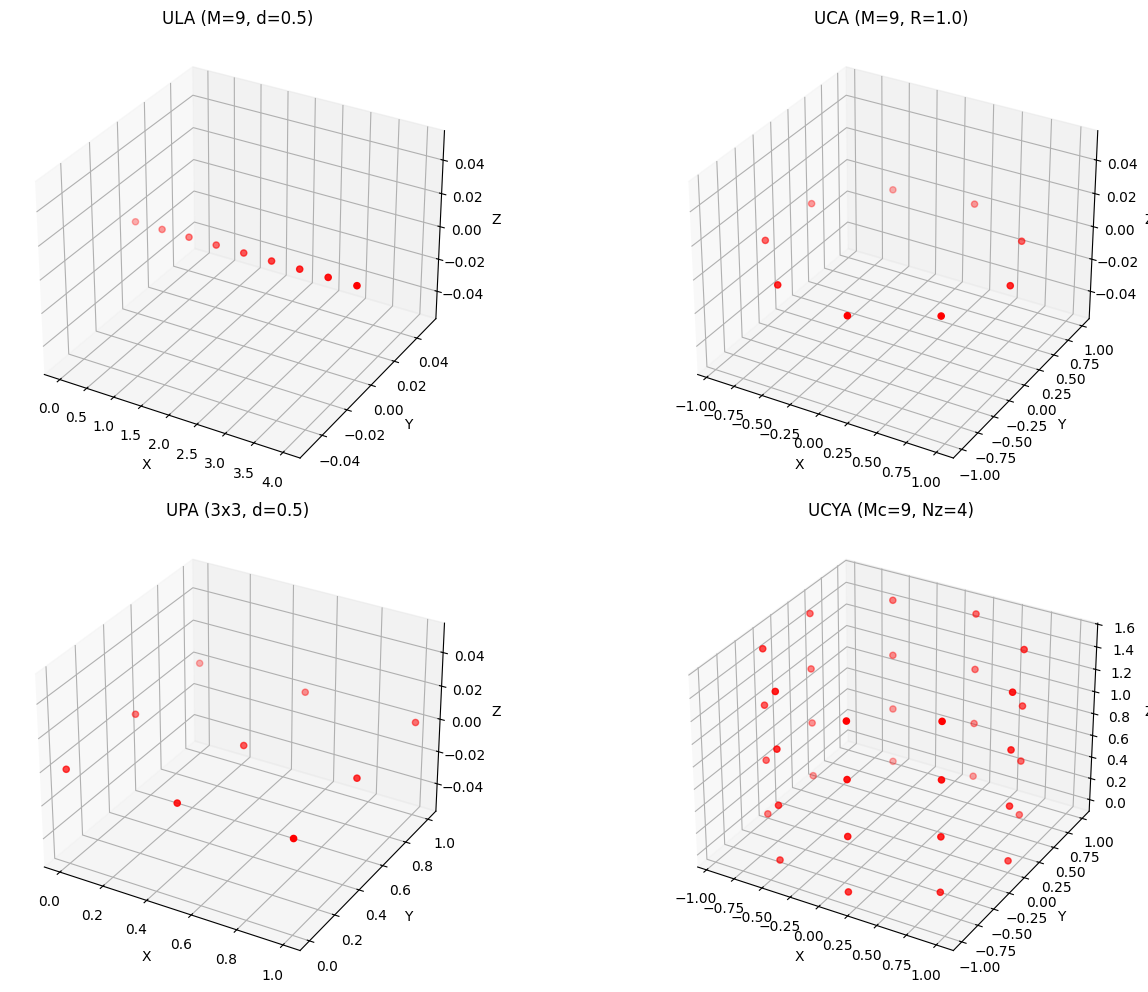

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_ula(M, d):
    """Arranjo Linear Uniforme (ULA)"""
    positions = np.zeros((M, 3))
    positions[:, 0] = np.arange(M) * d
    return positions

def generate_uca(M, R):
    """Arranjo Circular Uniforme (UCA)"""
    positions = np.zeros((M, 3))
    angles = np.linspace(0, 2 * np.pi, M, endpoint=False)
    positions[:, 0] = R * np.cos(angles)
    positions[:, 1] = R * np.sin(angles)
    return positions

def generate_upa(Mx, My, dx, dy):
    """Arranjo Planar Uniforme (UPA)"""
    positions = np.zeros((Mx * My, 3))
    for i in range(My):
        for j in range(Mx):
            positions[i * Mx + j, 0] = j * dx
            positions[i * Mx + j, 1] = i * dy
    return positions

def generate_ucya(Mc, Nz, R, dz):
    """Arranjo Cilíndrico Uniforme (UCYA)"""
    positions = np.zeros((Mc * Nz, 3))
    angles = np.linspace(0, 2 * np.pi, Mc, endpoint=False)
    for i in range(Nz):
        positions[i * Mc : (i + 1) * Mc, 0] = R * np.cos(angles)
        positions[i * Mc : (i + 1) * Mc, 1] = R * np.sin(angles)
        positions[i * Mc : (i + 1) * Mc, 2] = i * dz
    return positions

# Exemplo de visualização das geometrias
fig = plt.figure(figsize=(15, 10))

geoms = [
    (generate_ula(9, 0.5), "ULA (M=9, d=0.5)"),
    (generate_uca(9, 1.0), "UCA (M=9, R=1.0)"),
    (generate_upa(3, 3, 0.5, 0.5), "UPA (3x3, d=0.5)"),
    (generate_ucya(9, 4, 1.0, 0.5), "UCYA (Mc=9, Nz=4)")
]

for i, (pos, title) in enumerate(geoms):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c='r', marker='o')
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

plt.tight_layout()
plt.show()

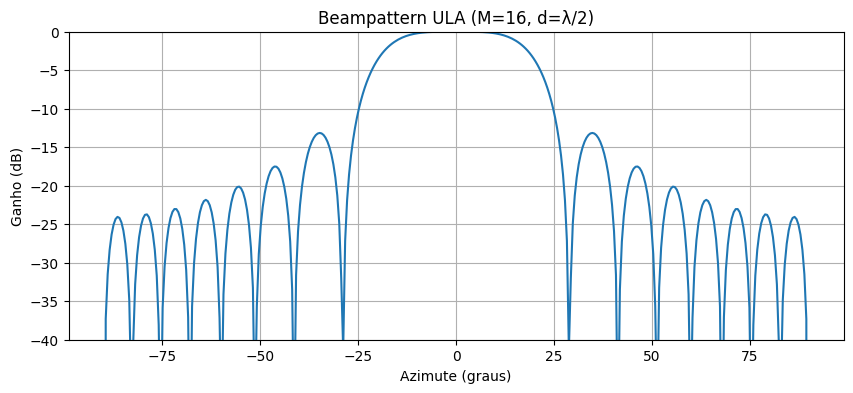

In [ ]:
def steering_vector(positions, azimuth, elevation, wavelength):
    """
    Calcula o vetor diretor para uma dada direção.
    azimuth e elevation em graus.
    """
    k = 2 * np.pi / wavelength
    az_rad = np.deg2rad(azimuth)
    el_rad = np.deg2rad(elevation)

    # Vetor unitário na direção da fonte
    u = np.array([
        np.cos(el_rad) * np.cos(az_rad),
        np.cos(el_rad) * np.sin(az_rad),
        np.sin(el_rad)
    ])

    # Fase: exp(j * k * positions . u)
    phases = np.dot(positions, u)
    return np.exp(1j * k * phases)

def beampattern(positions, az_range, el_range, wavelength, steer_az=0, steer_el=0):
    """
    Calcula o ganho do beampattern normalizado em dB.
    """
    w = steering_vector(positions, steer_az, steer_el, wavelength)
    B = []

    for az in az_range:
        for el in el_range:
            a = steering_vector(positions, az, el, wavelength)
            gain = np.abs(np.vdot(w, a))
            B.append(gain)

    B = np.array(B).reshape(len(az_range), len(el_range))
    B_db = 20 * np.log10(B / np.max(B))
    return B_db

# Exemplo de Beampattern para ULA (Tópico 5)
wavelength = 1.0
d = wavelength / 2
M = 16
positions_ula = generate_ula(M, d)
azimuths = np.linspace(-90, 90, 360)
elevations = [0]

B_ula = beampattern(positions_ula, azimuths, elevations, wavelength)

plt.figure(figsize=(10, 4))
plt.plot(azimuths, B_ula)
plt.title(f"Beampattern ULA (M={M}, d=λ/2)")
plt.xlabel("Azimute (graus)")
plt.ylabel("Ganho (dB)")
plt.grid(True)
plt.ylim([-40, 0])
plt.show()

In [ ]:
def beamformer(x, positions, steer_az, steer_el, wavelength):
    """
    Implementa o Delay-and-Sum Beamformer (Tópico 6).
    x: sinal recebido (M x N_samples)
    """
    w = steering_vector(positions, steer_az, steer_el, wavelength)
    # y = w^H * x
    y = np.dot(w.conj().T, x)
    return y

print("Funções dos tópicos 4, 5 e 6 implementadas com sucesso.")

Funções dos tópicos 4, 5 e 6 implementadas com sucesso.


In [ ]:
import re

# Procurando pelos tópicos 4, 5 e 6 no texto
# Geralmente em trabalhos acadêmicos, os tópicos são numerados como '4 ', '5 ', '6 ' no início de linhas ou seções.
topico_4 = re.search(r'\n4\s+(.*?)\n(?=\n\d\s+|$)', full_text, re.DOTALL)
topico_5 = re.search(r'\n5\s+(.*?)\n(?=\n\d\s+|$)', full_text, re.DOTALL)
topico_6 = re.search(r'\n6\s+(.*?)\n(?=\n\d\s+|$)', full_text, re.DOTALL)

def print_topic(num, match):
    if match:
        print(f'--- Tópico {num} ---\n{match.group(1).strip()}\n')
    else:
        print(f'--- Tópico {num} não encontrado via regex simples ---\n')

print_topic(4, topico_4)
print_topic(5, topico_5)
print_topic(6, topico_6)

# Se não encontrar, vamos imprimir uma parte maior do texto para análise manual
if not (topico_4 and topico_5 and topico_6):
    print('Conteúdo completo para busca manual:')
    print(full_text[1000:4000])

--- Tópico 4 ---
Gera¸c˜ao das Geometrias
Desenvolva fun¸c˜oes para gerar as coordenadas tridimen-
sionais dos elementos dos seguintes arranjos.
Arranjo Linear Uniforme (ULA): Implementar
a
fun¸c˜ao positions = generate_ula(M, d),
onde
M ∈N ´e o n´umero de sensores e d ∈R+ ´e o
espa¸camento entre sensores.
Prof. Rafael S. Chaves
Processamento de Sinais I
Modelagem e An´alise de Arranjos de Sensores
Arranjo Circular Uniforme (UCA): Implementar
a fun¸c˜ao positions = generate_uca(M, R), onde
M ∈N ´e o n´umero de sensores e R ∈R+ ´e o raio
do c´ırculo.
Arranjo Planar Uniforme (UPA): Implementar
a
fun¸c˜ao
positions = generate_upa(Mx, My, dx
, dy), onde Mx ∈N ´e o n´umero de sensores na
dire¸c˜ao horizontal, My ∈N ´e o n´umero de sensores
na dire¸c˜ao vertical, dx
∈R+ ´e o espa¸camento
horizontal e dy ∈R+ ´e o espa¸camento vertical.
Arranjo Cil´ındrico Uniforme: Implementar
a
fun¸c˜ao
positions = generate_ucya(Mc, Nz, R
, dz), onde Mc ∈N ´e o n´umero de sensores por
anel, Nz ∈N ´e o n´umer

```markdown
Acima, extraímos o texto do PDF. Agora, vou analisar o conteúdo para identificar as instruções específicas dos tópicos 4, 5 e 6 e implementar o código correspondente.
```